In [8]:
import pandas as pd
import numpy as np

data1 = pd.read_csv('Data/Ride Requests_2025-11-11-part-1.csv')
data2 = pd.read_csv('Data/Ride Requests_2025-11-11-part-2.csv')
data = pd.concat([data1, data2], ignore_index=True)
# data.to_csv('Data/rides.csv', index=False)

In [9]:
data

,Request Creation Time,Request Status,Number of Passengers,On Demand Pickup ETA Minutes,Origin Lat,Origin Lng,Destination Lat,Destination Lng,Actual Pickup Time,Actual Dropoff Time
0,1/1/2025 0:01,Completed,1,28.4,40.809092,-73.958766,40.814315,-73.959783,1/1/2025 0:29,1/1/2025 0:33
1,1/1/2025 0:01,Cancel,1,11.3,40.814027,-73.944593,40.805990,-73.960640,NaN,NaN
2,1/1/2025 0:04,Cancel,1,36.4,40.804654,-73.967158,40.813551,-73.961345,NaN,NaN
3,1/1/2025 0:04,Completed,1,5.7,40.808289,-73.955321,40.808428,-73.958698,1/1/2025 0:15,1/1/2025 0:21
4,1/1/2025 0:06,Completed,1,40.7,40.814052,-73.961161,40.809744,-73.959353,1/1/2025 0:33,1/1/2025 0:38
...,...,...,...,...,...,...,...,...,...,...
246791,10/31/2025 23:56,Seat Unavailable,1,13.8,40.802537,-73.964378,40.815560,-73.960450,NaN,NaN
246792,10/31/2025 23:56,Unaccepted Proposal,2,32.4,40.799054,-73.968383,40.809901,-73.957960,NaN,NaN
246793,10/31/2025 23:56,Completed,1,15.6,40.798640,-73.964071,40.813511,-73.960972,11/1/2025 0:27,11/1/2025 0:36
246794,10/31/2025 23:57,Cancel,2,28.2,40.804532,-73.962648,40.801334,-73.954032,NaN,NaN


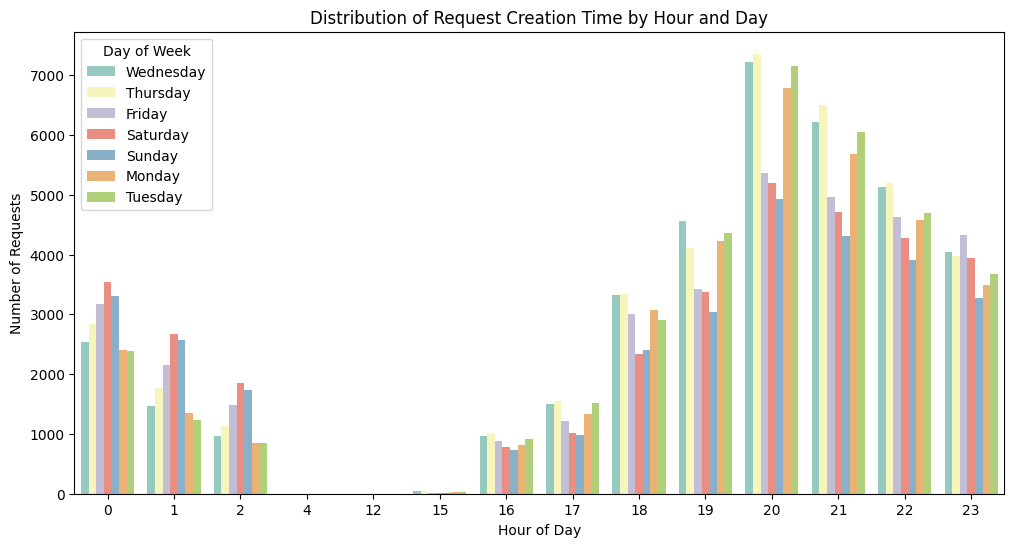

In [3]:
# visualize Request Creation Time distribution by day/hour
import matplotlib.pyplot as plt
import seaborn as sns
data['Request Creation Time'] = pd.to_datetime(data['Request Creation Time'])
data['Request Day'] = data['Request Creation Time'].dt.day_name()
data['Request Hour'] = data['Request Creation Time'].dt.hour
plt.figure(figsize=(12, 6))
sns.countplot(data=data, x='Request Hour', hue='Request Day', palette='Set3')
plt.title('Distribution of Request Creation Time by Hour and Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Requests')
plt.legend(title='Day of Week')
plt.show()

In [54]:
## Find average customer arrival rate by hour (monthly analysis)

### extracting date & hour of requests
data["request_time"] = pd.to_datetime(data["Request Creation Time"])
data["month"] = data["request_time"].dt.to_period("M")
data["date"] = data["request_time"].dt.date  
data["hour"] = data["request_time"].dt.hour

### count days per month 
days_by_month = data.groupby("month")["date"].nunique()

### total number of requests per hour (by month)
req_m_h = data.groupby(["month", "hour"]).size()

### arrival rate (by month)
arrival_rate = (req_m_h / days_by_month).reset_index(name="lambda_per_hour")

arrival_rate


,month,hour,lambda_per_hour
0,2025-01,0,43.451613
1,2025-01,1,23.064516
2,2025-01,2,15.516129
3,2025-01,15,1.774194
4,2025-01,16,80.225806
...,...,...,...
95,2025-10,19,143.483871
96,2025-10,20,171.064516
97,2025-10,21,157.838710
98,2025-10,22,135.161290


In [59]:
### Find Service Completion Rate by Hour (monthly analysis)

data["pickup_time"] = pd.to_datetime(data["Actual Pickup Time"], errors="coerce")
data["dropoff_time"] = pd.to_datetime(data["Actual Dropoff Time"], errors="coerce")

## keep only completed rides
completed = data[data["Request Status"] == "Completed"].copy()

## computing trip duration in minutes
completed["trip_min"] = (completed["dropoff_time"] - completed["pickup_time"]).dt.total_seconds()/60

## drop any system errors 
completed = completed[completed["trip_min"] > 0]

## average trip time (by hour, month)
service_rate = (completed.groupby(["month", "hour"])["trip_min"].mean().reset_index(name="avg_trip_min"))

## Service rate (trips per hour per driver) by (hour, month)
service_rate["avg_trip_hour"] = 60 / service_rate["avg_trip_min"]

service_rate


,month,hour,avg_trip_min,avg_trip_hour
0,2025-01,0,7.450602,8.053040
1,2025-01,1,6.444191,9.310710
2,2025-01,2,5.950820,10.082645
3,2025-01,15,8.413043,7.131783
4,2025-01,16,8.067246,7.437482
...,...,...,...,...
90,2025-10,19,8.413517,7.131382
91,2025-10,20,9.761140,6.146823
92,2025-10,21,9.500749,6.315292
93,2025-10,22,9.248325,6.487661


In [65]:
## calculate actual rho (hour, month) - rho > 1: customers wait too long
## formula: rho = arrival rate / (average # of drivers by hour * service rate)

drivers = pd.read_csv('Data/drivers.csv')
drivers["Date"] = pd.to_datetime(drivers["Date"])

## change from wide format to long
drivers = drivers.melt(
    id_vars=["Date", "Day"],
    value_vars=["4p-5p", "5p-6p", "6p-7p", "7p-8p", "8p-9p", "9p-10p", "10p-11p", "11p-12a", "12a-1a", "1a-2a", "2a-3a"],
    var_name="time window"
)

## extract month
drivers["month"] = drivers["Date"].dt.to_period("M")

## map each time period to actual hour
hour_map = {
    "4p-5p":16, "5p-6p":17, "6p-7p":18, "7p-8p":19, "8p-9p":20,
    "9p-10p":21, "10p-11p":22, "11p-12a":23,
    "12a-1a":0, "1a-2a":1, "2a-3a":2
}


## concat
drivers["hour"] = drivers["time window"].map(hour_map)

## average # of drivers per hour across all october days 
drivers = (
    drivers.groupby(["month", "hour"])["value"]
    .mean()
    .reset_index(name="avg_drivers_hour")
)

drivers

,month,hour,avg_drivers_hour
0,2025-10,0,10.967742
1,2025-10,1,7.935484
2,2025-10,2,6.225806
3,2025-10,16,0.000000
4,2025-10,17,0.000000
5,2025-10,18,7.032258
6,2025-10,19,8.032258
7,2025-10,20,16.064516
8,2025-10,21,16.064516
9,2025-10,22,16.064516


In [73]:
# Merged dataset: λ, μ, and drivers
"""
note, because we were only given information about the actual # of drivers in october,
we will use october numbers (avg # of drivers) across all the other months. 
"""
merged = (
    arrival_rate
    .merge(service_rate[["month", "hour", "avg_trip_hour"]], on=["month", "hour"], how="left")
    .merge(drivers, on="hour", how="left")
)

## formula: rho = arrival rate / (average # of drivers by hour * service rate)
merged["rho_actual"] = (
    merged["lambda_per_hour"] /
    (merged["avg_drivers_hour"] * merged["avg_trip_hour"])
)

merged = merged.drop(columns=["month_y"]).rename(columns={"month_x": "month"})

## filter by hours where via is actually in service
"""
comment: because we were only given information about drivers in october, we can only
apply october's operational hours onto the other months (from 6pm-3am). 
"""
service_hours = [18,19,20,21,22,23,0,1,2,3]
merged = merged[merged["hour"].isin(service_hours)]

merged

,month,hour,lambda_per_hour,avg_trip_hour,avg_drivers_hour,rho_actual
0,2025-01,0,43.451613,8.053040,10.967742,0.491959
1,2025-01,1,23.064516,9.310710,7.935484,0.312168
2,2025-01,2,15.516129,10.082645,6.225806,0.247180
6,2025-01,18,124.000000,7.261803,7.032258,2.428189
7,2025-01,19,121.870968,7.747101,8.032258,1.958499
...,...,...,...,...,...,...
95,2025-10,19,143.483871,7.131382,8.032258,2.504908
96,2025-10,20,171.064516,6.146823,16.064516,1.732374
97,2025-10,21,157.838710,6.315292,16.064516,1.555795
98,2025-10,22,135.161290,6.487661,16.064516,1.296870


In [80]:
"""
rho represents the utilization of the system (ρ measures how “busy” your fleet is relative to its capacity.) 
First, we filter to see the months/hour where rho > 1 <=> via is understaffed
"""

## understaffed
understaffed = merged[merged["rho_actual"]>1].copy()

"""
ideal industry (uber,lyft) rho ~ 0.85. using this value (can play around with this #),
want to find ideal avg # of drivers for currently understaffed (hours,month)

formula: c* = (arrival rate) / (rho* = 0.85 * service rate)
"""

## ideal drivers (not rounded)
understaffed["ideal_drivers_hour"] = understaffed["lambda_per_hour"]/(0.85*understaffed["avg_trip_hour"])

## difference in ideal - current (not rounded)
understaffed["drivers_needed"] = (understaffed["ideal_drivers_hour"] - understaffed["avg_drivers_hour"])

## ^^ drivers needed (rounded)
understaffed["drivers_needed_rounded"] = np.ceil(understaffed["drivers_needed"]).astype(int)

understaffed


,month,hour,lambda_per_hour,avg_trip_hour,avg_drivers_hour,rho_actual,ideal_drivers_hour,drivers_needed,drivers_needed_rounded
6,2025-01,18,124.000000,7.261803,7.032258,2.428189,20.089000,13.056742,14
7,2025-01,19,121.870968,7.747101,8.032258,1.958499,18.507260,10.475002,11
8,2025-01,20,128.290323,6.593379,16.064516,1.211207,22.891115,6.826599,7
9,2025-01,21,113.741935,6.914522,16.064516,1.023978,19.352610,3.288094,4
12,2025-02,0,99.000000,7.410755,10.967742,1.218023,15.716428,4.748686,5
13,2025-02,1,64.964286,8.011218,7.935484,1.021887,9.540194,1.604710,2
18,2025-02,18,198.785714,6.878053,7.032258,4.109839,34.001705,26.969447,27
19,2025-02,19,213.392857,7.177534,8.032258,3.701408,34.977254,26.944996,27
20,2025-02,20,233.250000,6.061422,16.064516,2.395408,45.271847,29.207330,30
21,2025-02,21,212.071429,6.163724,16.064516,2.141763,40.478094,24.413578,25
